In [56]:
# step 0 : importing the tools
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [57]:
#step 1 : Loading the data
print("_"*100)   

np.random.seed(42)

data = {
    'systolic_bp':   np.concatenate([np.random.normal(118, 10, 150),
                                     np.random.normal(142, 12, 150),
                                     np.random.normal(168, 8,  100)]),
    'cholesterol':   np.concatenate([np.random.normal(178, 18, 150),
                                     np.random.normal(222, 22, 150),
                                     np.random.normal(262, 18, 100)]),
    'bmi':           np.concatenate([np.random.normal(21.5, 2, 150),
                                     np.random.normal(27.0, 3, 150),
                                     np.random.normal(33.5, 3, 100)]),
    'glucose_level': np.concatenate([np.random.normal(88,  10, 150),
                                     np.random.normal(112, 14, 150),
                                     np.random.normal(148, 18, 100)]),
    'age':           np.concatenate([np.random.normal(34, 7,  150),
                                     np.random.normal(51, 6,  150),
                                     np.random.normal(63, 5,  100)])
}

df_orignal  = pd.DataFrame(data)
#making the copy of original dataframe
df=df_orignal.copy()

# Step 2 : appling the Principal Component Analysis . to data to compress the  features to 2 peremeters only
    
    # Scaling the data
scaler=StandardScaler()
df=scaler.fit_transform(df)
df=pd.DataFrame(df,columns=['systolic_bp','cholesterol','bmi','glucose_level','age'])
print("--------","Scaled Data Without PCA","--------")
display(df)

    # Appling the Principle Component Analysis
pca=PCA(n_components=2)
df=pca.fit_transform(df)
df=pd.DataFrame(df,columns=["Principle Component 1","Principle Component 2"])
print("--------","Scaled Data With PCA","--------")
display(df)


____________________________________________________________________________________________________
-------- Scaled Data Without PCA --------


,systolic_bp,cholesterol,bmi,glucose_level,age
0,-0.743589,-1.672401,-0.654825,-0.874741,-1.222482
1,-1.025337,-1.215416,-1.196651,-1.083512,-0.353914
2,-0.676600,-0.937740,-0.968582,-0.875842,-1.480675
3,-0.288200,-0.918572,-1.176618,-0.717371,-1.566111
4,-1.067884,-1.146844,-1.166269,-0.903485,-1.389668
...,...,...,...,...,...
395,1.088032,1.686721,1.477128,0.652476,1.615633
396,0.646464,1.184887,1.219998,1.756125,1.178868
397,1.735159,1.516037,1.539726,2.730671,0.838211
398,1.213917,1.216059,1.356105,1.350707,1.124486


-------- Scaled Data With PCA --------


,Principle Component 1,Principle Component 2
0,-2.309357,0.394254
1,-2.178584,-0.336967
2,-2.208597,0.365879
3,-2.085668,0.601701
4,-2.538520,0.323611
...,...,...
395,2.917338,-0.819291
396,2.671795,0.386364
397,3.733220,1.348124
398,2.799342,0.147944


______________________________________________________________________________________________________________________________________________________


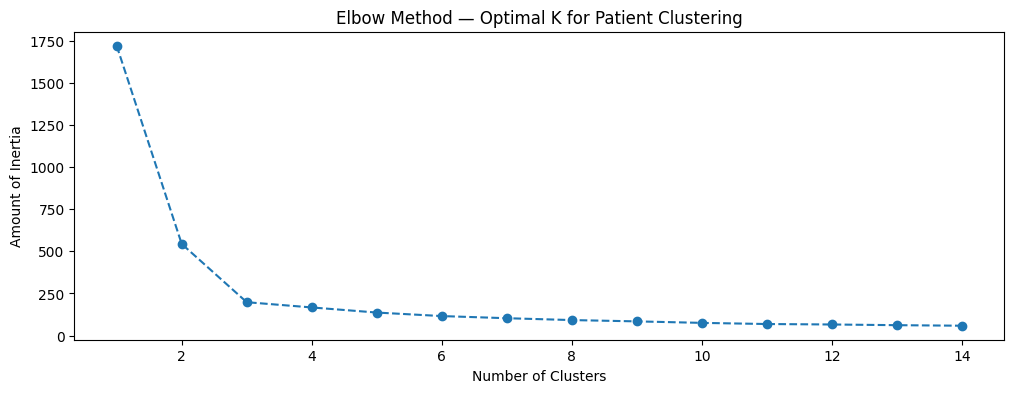

In [58]:
print("_"*150)
# step 3 : Finding the optimal K 
wcss=[]
for k in range(1,15):
    kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42)
    kmeans.fit(df)
    inertia=kmeans.inertia_
    wcss.append(inertia)

    # Plotting the graph of k v/s wcss
plt.figure(figsize=(12,4))

plt.plot(range(1,15),wcss,marker="o",linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Amount of Inertia")
plt.title("Elbow Method — Optimal K for Patient Clustering")
plt.show()



______________________________________________________________________________________________________________________________________________________


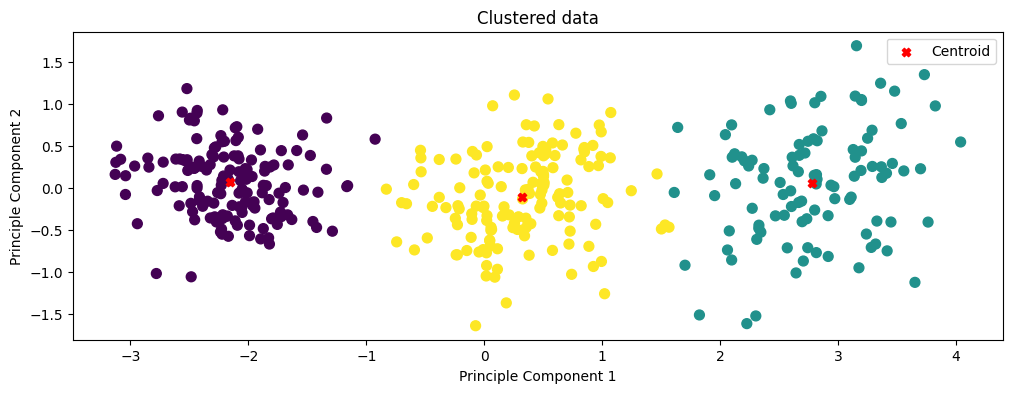

In [59]:
# step 4 : training the actual KMEans model
print()
print("_"*150)
kmeans=KMeans(n_clusters=3,init="k-means++",n_init=10,random_state=42)
kmeans.fit(df)
labels=kmeans.predict(df)

plt.figure(figsize=(12,4))
plt.scatter(df["Principle Component 1"],df["Principle Component 2"],c=labels,cmap="viridis",s=50)
center=kmeans.cluster_centers_
plt.scatter(center[:,0],center[:,1],c="red",marker="X",label="Centroid")
plt.legend()
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.title("Clustered data")
plt.show()

In [60]:
# step 5 : printing the summary table 
df_orignal["Cluster"]=kmeans.labels_

summary_table=df_orignal.groupby("Cluster").mean()
summary_table

,systolic_bp,cholesterol,bmi,glucose_level,age
Cluster,,,,,
0,117.613482,175.905372,21.859512,88.433889,35.384784
1,168.756161,261.596647,33.721531,146.028734,63.253098
2,142.635891,223.053648,27.397456,114.283125,50.767223
